In [1]:
import pandas as pd
import numpy as np

---

## Level 1 — Conference registrations

An event organizer exported their registration list. Before dropping duplicates, they want to understand exactly what kind of duplication exists.

**New this week — `df.duplicated()`**

Returns a boolean Series marking rows that are duplicates:

```python
df.duplicated()             # True for 2nd+ occurrence of a duplicate row
df.duplicated(keep=False)   # True for ALL occurrences (including the first)
df[df.duplicated()]         # show only the duplicate rows
df[df.duplicated(keep=False)]  # show every row involved in a duplicate
df.duplicated().sum()       # count how many rows are duplicates
```

It also accepts `subset=` to check duplicates on specific columns only:

```python
df.duplicated(subset=['email'])   # True when the same email appears more than once
```

Work through these in order:

1. How many rows are exact duplicates? Print the duplicate rows so you can see them.
2. Some attendees registered for a second session — same email, different `session`. How many rows have a repeated email? Use `duplicated(subset=['email'])`.
3. Drop exact duplicates. Standardize `session` and `ticket` to lowercase.
4. How many attendees are in each session? Use `np.unique` to confirm the distinct session values first.

In [16]:
registrations = pd.DataFrame({
    'name':    ['Alice Brown', 'Bob Green', 'Carol White', 'Dave Hall', 'Eve Scott',
                'Alice Brown', 'Frank Lee', 'Bob Green',   'Grace Kim'],
    'email':   ['alice@x.com', 'bob@x.com', 'carol@x.com', 'dave@x.com', 'eve@x.com',
                'alice@x.com', 'frank@x.com', 'bob@x.com',  'grace@x.com'],
    'session': ['Morning', 'Afternoon', 'Morning',  'Evening',   'Afternoon',
                'Morning', 'Evening',   'Workshop', 'Morning'],
    'ticket':  ['standard', 'vip', 'premium', 'standard', 'vip',
                'standard', 'standard', 'vip',      'premium'],
})

# Your code here
print(registrations.loc[registrations.duplicated()])
print(registrations.duplicated().sum(), 'are exact duplicates')
print(registrations.duplicated(subset = ['email']).sum(),'have a repeated email')
d = registrations.drop_duplicates().copy()
d['session'] = d['session'].str.lower()
d['ticket'] = d['ticket'].str.lower()

g = d.groupby('session')['name'].apply(lambda x: len(np.unique(x)))
print(g)

          name        email  session    ticket
5  Alice Brown  alice@x.com  Morning  standard
1 are exact duplicates
2 have a repeated email
session
afternoon    2
evening      2
morning      3
workshop     1
Name: name, dtype: int64


---

## Level 2 — Music streaming catalog

A label exported tracks from four artists. Two tracks appear twice (exact duplicates). The `streams` column has `'N/A'` strings and `revenue` is stored with `$` and `,`.

Clean the data — no steps provided — then answer:

- How many exact duplicates exist? Use `duplicated()` before dropping.
- Which artist has the highest total revenue across all their tracks?
- Drop rows with missing streams, then compute the correlation between streams and revenue. Use `np.corrcoef`.
- What is the 75th percentile revenue across all tracks (including those with no stream data)? Use `np.nanpercentile`.
- Which genre has the most tracks in the cleaned catalog?

In [40]:
tracks = pd.DataFrame({
    'track_id': ['TR01','TR02','TR03','TR04','TR05','TR06','TR07','TR08',
                 'TR09','TR10','TR11','TR12','TR01','TR07'],
    'artist':   ['The Waves','SOLAR','the waves','Echo Park','ECHO PARK',
                 'Solar','Midnight Run','MIDNIGHT RUN','The Waves','echo park',
                 'Solar','Midnight Run','The Waves','Midnight Run'],
    'genre':    ['Pop','indie','pop','Rock','rock',
                 'Indie','jazz','JAZZ','Pop','Rock',
                 'POP','Jazz','Pop','jazz'],
    'streams':  [1200000, 850000, 'N/A', 2100000, 450000,
                 980000, 340000, 'N/A', 780000, 1650000,
                 720000, 560000, 1200000, 340000],
    'revenue':  ['$4,800','$3,200','$2,900','$8,400','$1,650',
                 '$4,100','$1,200','$890','$3,300','$7,200',
                 '$2,750','$2,100','$4,800','$1,200'],
})

# Your code here
print(tracks.duplicated().sum(),'exact duplicates')
d = tracks.drop_duplicates().copy()
d['artist'] = d['artist'].str.lower()
d['revenue'] = d['revenue'].str.replace('$','',regex = False)
d['revenue'] = d['revenue'].str.replace(',','',regex = False)
d['revenue'] = pd.to_numeric(d['revenue'])
d['genre'] = d['genre'].str.lower()
print(d.groupby('artist')['revenue'].sum().idxmax(),'has the higehst revenue')
d['streams'] = pd.to_numeric(d['streams'], errors='coerce')
dm = d[~d['streams'].isna()]
cc = np.corrcoef(dm['streams'], dm['revenue'])[0,1]
print('correlation is: ', cc)
qq = np.nanpercentile(d['revenue'],75)
print('75th percentile is: ', qq)
print(dm.groupby('genre')['track_id'].count().idxmax(),'has the most')

2 exact duplicates
echo park has the higehst revenue
correlation is:  0.9961474906963641
75th percentile is:  4275.0
pop has the most


---

## Level 3 — Customer support tickets

Sixteen support tickets (one duplicate) exported from a helpdesk system. No function stubs — build the pipeline yourself.

Known issues:
- `ticket_id`: one exact duplicate
- `category`: inconsistent casing
- `priority`: codes 1/2/3 — replace with `'low'`/`'medium'`/`'high'`
- `wait_hrs`: some `'n/a'` strings
- `resolved`: `'yes'`/`'YES'`/`'no'`/`'No'` — standardize to lowercase
- `open_date`: some `'TBD'` entries

After cleaning:

1. Which category has the longest average wait time (excluding unknowns)? Use `np.nanmean` per group.
2. What fraction of tickets are resolved? Use `np.mean` on a boolean comparison.
3. Do high-priority tickets have shorter or longer wait times than low-priority tickets? Compare `np.nanmean` for each.
4. Log-transform valid wait times with `np.log`. What is the 90th percentile log-wait? Use `np.nanpercentile`.
5. How many customers submitted more than one ticket? Use `duplicated(subset=['customer'], keep=False)` to mark repeat customers, then count distinct ones.

billing has the highest average wait time
0.6666666666666666 are resolved
high and mediumn have lower wait time that low priority
1.5883658093025352 is the 90th percentile of log wait time
12 unique customers


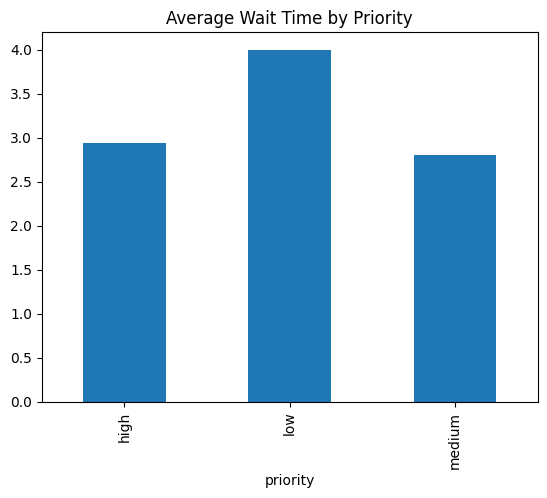

In [50]:
tickets = pd.DataFrame({
    'ticket_id': ['T001','T002','T003','T004','T005','T006','T007','T008',
                  'T009','T010','T011','T012','T013','T014','T015','T003'],
    'customer':  ['alice@co.com','bob@co.com','carol@co.com','dave@co.com','eve@co.com',
                  'alice@co.com','frank@co.com','grace@co.com','henry@co.com','ivy@co.com',
                  'alice@co.com','bob@co.com','jack@co.com','karen@co.com','liam@co.com',
                  'carol@co.com'],
    'category':  ['Billing','TECHNICAL','billing','Technical','BILLING',
                  'technical','Billing','TECHNICAL','billing','Technical',
                  'Billing','technical','BILLING','Technical','billing','billing'],
    'priority':  [1, 2, 3, 1, 2, 3, 1, 2, 1, 3, 2, 1, 3, 2, 1, 3],
    'wait_hrs':  [2.5, 4.0, 1.5, 'n/a', 3.2, 5.5, 2.0, 1.8, 4.5, 'n/a', 3.8, 2.2, 5.0, 1.2, 3.5, 1.5],
    'resolved':  ['yes','YES','no','Yes','no','YES','yes','No',
                  'yes','YES','no','yes','YES','no','yes','no'],
    'open_date': ['2024-01-05','2024-01-08','2024-01-12','2024-01-15','2024-02-01',
                  '2024-02-10','2024-02-18','2024-03-02','2024-03-15','2024-03-22',
                  '2024-04-05','2024-04-18','2024-05-01','2024-05-14','2024-05-28',
                  '2024-01-12'],
})

# Your code here
def clean(df):
    df = df.drop_duplicates().copy()
    df['category'] = df['category'].str.lower()
    df['resolved'] = df['resolved'].str.lower()
    df['wait_hrs'] = pd.to_numeric(df['wait_hrs'], errors='coerce')
    df['open_date'] = pd.to_datetime(df['open_date'], errors='coerce')
    df['priority'] = df['priority'].replace({1:'high', 2:'medium', 3:'low'})
    return df
c = clean(tickets)


print(c.groupby('category')['wait_hrs'].apply(lambda x: np.nanmean(x)).idxmax() + ' has the highest average wait time')
print(np.mean(c['resolved'] == 'yes'),'are resolved')
c.groupby('priority')['wait_hrs'].apply(lambda x: np.nanmean(x)).plot(kind = 'bar', title = 'Average Wait Time by Priority')
print('high and mediumn have lower wait time that low priority')
c['log_wait'] = np.log(c['wait_hrs'])
print(np.nanpercentile(c['log_wait'], 90),'is the 90th percentile of log wait time')
c['mark'] = c.duplicated(subset = ['customer'],keep = False)
print(c['customer'].unique().shape[0], 'unique customers')

1. Which category has the longest average wait time (excluding unknowns)? Use `np.nanmean` per group.
2. What fraction of tickets are resolved? Use `np.mean` on a boolean comparison.
3. Do high-priority tickets have shorter or longer wait times than low-priority tickets? Compare `np.nanmean` for each.
4. Log-transform valid wait times with `np.log`. What is the 90th percentile log-wait? Use `np.nanpercentile`.
5. How many customers submitted more than one ticket? Use `duplicated(subset=['customer'], keep=False)` to mark repeat customers, then count distinct ones.

In [49]:
c

,ticket_id,customer,category,priority,wait_hrs,resolved,open_date,log_wait,mark
0,T001,alice@co.com,billing,high,2.5,yes,2024-01-05,0.916291,True
1,T002,bob@co.com,technical,medium,4.0,yes,2024-01-08,1.386294,True
2,T003,carol@co.com,billing,low,1.5,no,2024-01-12,0.405465,False
3,T004,dave@co.com,technical,high,NaN,yes,2024-01-15,NaN,False
4,T005,eve@co.com,billing,medium,3.2,no,2024-02-01,1.163151,False
5,T006,alice@co.com,technical,low,5.5,yes,2024-02-10,1.704748,True
6,T007,frank@co.com,billing,high,2.0,yes,2024-02-18,0.693147,False
7,T008,grace@co.com,technical,medium,1.8,no,2024-03-02,0.587787,False
8,T009,henry@co.com,billing,high,4.5,yes,2024-03-15,1.504077,False
9,T010,ivy@co.com,technical,low,NaN,yes,2024-03-22,NaN,False
